In [1]:
from typing import TypedDict

class Portfoliostate(TypedDict):
    amount_usd: float
    total_usd : float
    total_inr : float


In [2]:
# Createa nodes

def cal_amount_usd(state : Portfoliostate) -> Portfoliostate:
    state['total_usd'] = state['amount_usd'] * 1.0
    return state

def cal_total_inr(state : Portfoliostate) -> Portfoliostate:
    state['total_inr'] = state['total_usd'] * 82.0
    return state


In [5]:
# Nodes and Edges

from langgraph.graph import StateGraph, START, END

builder = StateGraph(Portfoliostate)

builder.add_node('amnt_usd_node', cal_amount_usd)
builder.add_node('total_inr_node', cal_total_inr)

builder.add_edge(START, 'amnt_usd_node')
builder.add_edge('amnt_usd_node', 'total_inr_node')
builder.add_edge('total_inr_node', END)

graph = builder.compile()

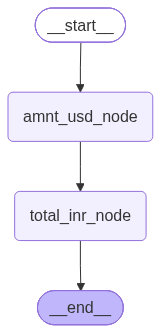

In [6]:
# Visulaize the graph
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
initial_state = {'amount_usd': 100.0, 'total_usd': 0.0, 'total_inr': 0.0}

graph.invoke(initial_state)

{'amount_usd': 100.0, 'total_usd': 100.0, 'total_inr': 8200.0}